# Aerospace Supply Chain Risk — Exploratory Data Analysis

Day 11 of 21. Visualizes state- and sector-level concentration risk scores produced by the Phase 2 pipeline.

**Inputs:** `data/processed/supplier_segments.csv` and `data/processed/supply_chain.db`.

**Outputs:** four PNG charts written to `outputs/`.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CSV_PATH = PROJECT_ROOT / 'data' / 'processed' / 'supplier_segments.csv'
DB_PATH = PROJECT_ROOT / 'data' / 'processed' / 'supply_chain.db'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

TIER_COLORS = {'High': '#d62728', 'Medium': '#ff7f0e', 'Low': '#2ca02c', 'Minimal': '#7f7f7f'}

sns.set_style('whitegrid')

df_csv = pd.read_csv(CSV_PATH)
with sqlite3.connect(DB_PATH) as conn:
    df_db = pd.read_sql_query('SELECT * FROM supplier_segments', conn)

print('CSV rows:', len(df_csv), '| DB rows:', len(df_db))
df = df_csv
states = df[df['row_type'] == 'STATE'].copy()
naics = df[df['row_type'] == 'NAICS'].copy()
print('STATE rows:', len(states), '| NAICS rows:', len(naics))
df.head()

CSV rows: 56 | DB rows: 56
STATE rows: 52 | NAICS rows: 4


,row_type,naics_code,naics_label,state,total_contract_value,recipient_count,export_value,employment_count,hhi_score,concentration_risk_label,geo_risk_score,workforce_risk_score,composite_risk_score,risk_tier
0,NAICS,336411.0,Aircraft Manufacturing,NaN,NaN,NaN,1.000223e+10,240989.0,NaN,NaN,60.42,32.44,46.43,Medium
1,NAICS,336412.0,Aircraft Engine & Engine Parts Manufacturing,NaN,NaN,NaN,NaN,86578.0,NaN,NaN,NaN,4.54,4.54,Low
2,NAICS,336413.0,Other Aircraft Parts & Equipment Manufacturing,NaN,NaN,NaN,5.099478e+08,100422.0,NaN,NaN,30.37,3.70,17.04,Low
3,NAICS,336414.0,Guided Missile & Space Vehicle Manufacturing,NaN,NaN,NaN,7.658276e+08,NaN,NaN,NaN,37.98,NaN,37.98,Low
4,STATE,NaN,NaN,AK,93609999.83,6.0,NaN,NaN,7758.47,High,NaN,NaN,77.58,High


## Chart 1 — Top 20 Highest Risk States

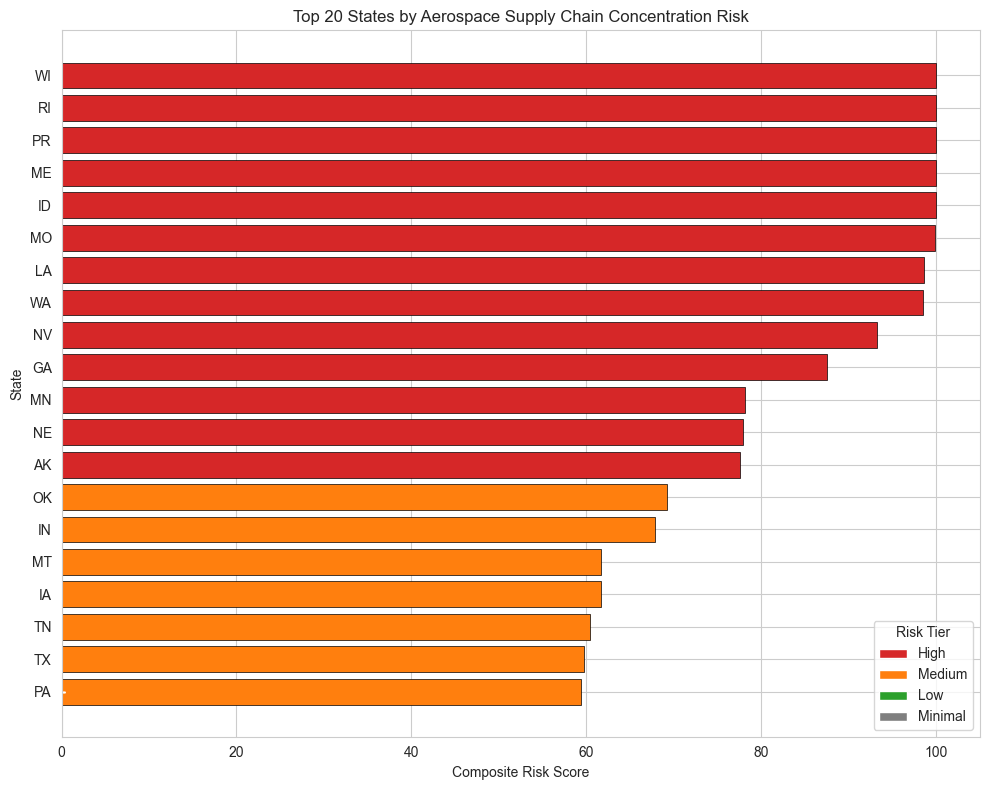

saved -> /Users/shravankumaar/aerospace-supply-chain-risk-ai/outputs/chart1_top20_states.png


In [2]:
top20 = states.dropna(subset=['composite_risk_score']).sort_values('composite_risk_score', ascending=False).head(20)
top20 = top20.iloc[::-1]
colors = [TIER_COLORS.get(t, '#7f7f7f') for t in top20['risk_tier']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['state'], top20['composite_risk_score'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Composite Risk Score')
ax.set_ylabel('State')
ax.set_title('Top 20 States by Aerospace Supply Chain Concentration Risk')
ax.set_xlim(0, 105)
for tier, color in TIER_COLORS.items():
    ax.bar(0, 0, color=color, label=tier)
ax.legend(title='Risk Tier', loc='lower right')
plt.tight_layout()
out_path = OUTPUTS_DIR / 'chart1_top20_states.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved ->', out_path)

## Chart 2 — Risk Score Distribution

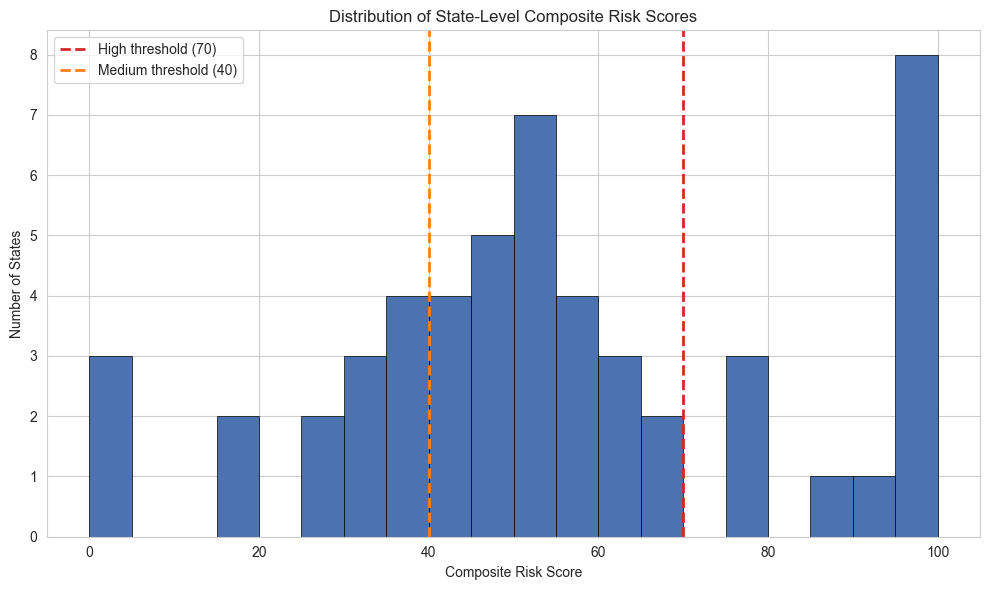

saved -> /Users/shravankumaar/aerospace-supply-chain-risk-ai/outputs/chart2_risk_distribution.png


In [3]:
scores = states['composite_risk_score'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(scores, bins=20, color='#4c72b0', edgecolor='black', linewidth=0.5)
ax.axvline(70, color='#d62728', linestyle='--', linewidth=2, label='High threshold (70)')
ax.axvline(40, color='#ff7f0e', linestyle='--', linewidth=2, label='Medium threshold (40)')
ax.set_xlabel('Composite Risk Score')
ax.set_ylabel('Number of States')
ax.set_title('Distribution of State-Level Composite Risk Scores')
ax.legend()
plt.tight_layout()
out_path = OUTPUTS_DIR / 'chart2_risk_distribution.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved ->', out_path)

## Chart 3 — NAICS Sector Risk Heatmap

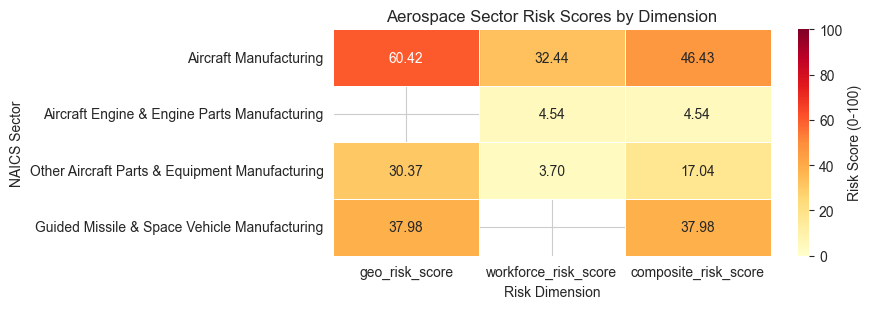

saved -> /Users/shravankumaar/aerospace-supply-chain-risk-ai/outputs/chart3_naics_heatmap.png


In [4]:
heatmap_cols = ['geo_risk_score', 'workforce_risk_score', 'composite_risk_score']
heat_df = naics.set_index('naics_label')[heatmap_cols]

fig, ax = plt.subplots(figsize=(9, max(3, 0.8 * len(heat_df))))
sns.heatmap(
    heat_df,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Risk Score (0-100)'},
    ax=ax,
)
ax.set_title('Aerospace Sector Risk Scores by Dimension')
ax.set_xlabel('Risk Dimension')
ax.set_ylabel('NAICS Sector')
plt.tight_layout()
out_path = OUTPUTS_DIR / 'chart3_naics_heatmap.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved ->', out_path)

## Chart 4 — Contract Value vs Risk Score

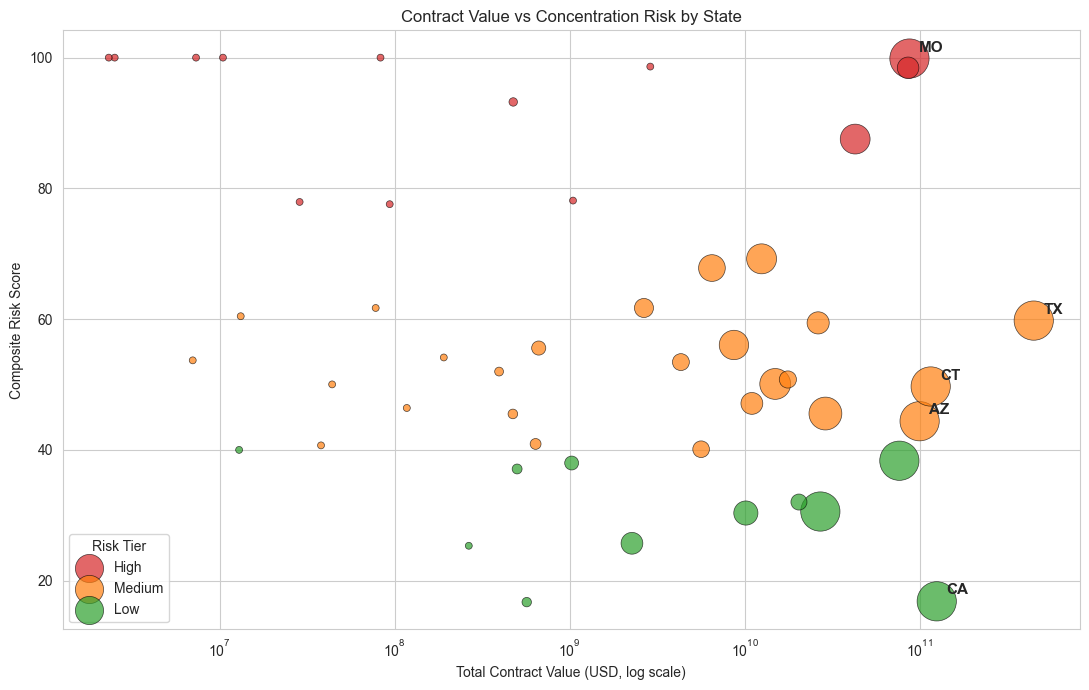

saved -> /Users/shravankumaar/aerospace-supply-chain-risk-ai/outputs/chart4_contract_vs_risk.png


In [5]:
scatter_df = states.dropna(subset=['total_contract_value', 'composite_risk_score', 'recipient_count']).copy()
scatter_df = scatter_df[scatter_df['total_contract_value'] > 0]

fig, ax = plt.subplots(figsize=(11, 7))
for tier, color in TIER_COLORS.items():
    sub = scatter_df[scatter_df['risk_tier'] == tier]
    if sub.empty:
        continue
    ax.scatter(
        sub['total_contract_value'],
        sub['composite_risk_score'],
        s=np.clip(sub['recipient_count'] * 1.5, 25, 800),
        c=color,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5,
        label=tier,
    )

top5 = scatter_df.nlargest(5, 'total_contract_value')
for _, row in top5.iterrows():
    ax.annotate(
        row['state'],
        (row['total_contract_value'], row['composite_risk_score']),
        xytext=(7, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
    )

ax.set_xscale('log')
ax.set_xlabel('Total Contract Value (USD, log scale)')
ax.set_ylabel('Composite Risk Score')
ax.set_title('Contract Value vs Concentration Risk by State')
ax.legend(title='Risk Tier', loc='lower left')
plt.tight_layout()
out_path = OUTPUTS_DIR / 'chart4_contract_vs_risk.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved ->', out_path)

In [6]:
summary = {
    'top_state': top20.iloc[-1]['state'],
    'top_score': top20.iloc[-1]['composite_risk_score'],
    'high_count': int((states['risk_tier'] == 'High').sum()),
    'medium_count': int((states['risk_tier'] == 'Medium').sum()),
    'low_count': int((states['risk_tier'] == 'Low').sum()),
    'minimal_count': int((states['risk_tier'] == 'Minimal').sum()),
    'mean_score': scores.mean(),
    'median_score': scores.median(),
    'top_contract_state': top5.iloc[0]['state'],
    'top_contract_value': top5.iloc[0]['total_contract_value'],
    'top_contract_score': top5.iloc[0]['composite_risk_score'],
}
summary

{'top_state': 'WI',
 'top_score': np.float64(100.0),
 'high_count': 13,
 'medium_count': 25,
 'low_count': 11,
 'minimal_count': 3,
 'mean_score': np.float64(54.96423076923077),
 'median_score': np.float64(51.364999999999995),
 'top_contract_state': 'TX',
 'top_contract_value': np.float64(449756620367.95),
 'top_contract_score': np.float64(59.77)}

## Key Findings

- **Concentration risk is widespread at the state level.** 13 states fall in the High tier (composite score >= 70), with ID, ME, PR, RI, WI, MO (99.86), WA (98.44), and LA (98.63) all scoring at or above 98 — most of these are low-recipient states where one or two suppliers dominate, producing near-maximum HHI.
- **The distribution is bimodal.** Mean state risk is ~54 and median ~50, but the histogram shows a heavy cluster in the 25-65 Medium band (~25 states) alongside a second mode in the 95-100 range driven by single-supplier states; only ND, SD, and WY register Minimal (score 0).
- **Top contract-value states are not the riskiest.** TX leads at $449.8B in contract value but scores only 59.77 (Medium); CA ($125B) sits at 16.82 (Low). The scatter shows that diversified, high-volume states cluster in the lower-risk band, while the highest-risk states (LA, MO, WA) combine multi-billion-dollar awards with very few recipients.